In [35]:
library(ggplot2)
library(scattermore)
# integration data
# 

# https=//satijalab.org/seurat/articles/seurat5_integration

.libPaths(c('/sc/arion/projects/CommonMind/liting/conda/envs/Py39_R43_Ju10/lib/R/library',.libPaths()))
library(RColorBrewer)
library(scales)
library(schard)
library(SeuratWrappers)
library(ggVennDiagram)
library(Seurat)
library(slingshot)
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(zellkonverter)
# functions 
# intergrate NN and ENT data, and perform trajectory inference

library(Seurat)
library(dplyr)
library(Seurat)
library(patchwork)

library(BiocManager)

library(scuttle)
library(reticulate)
library(Seurat)
library(uwot)
library(stringr)


library(ggplot2)
library(ggplot2)
library(scattermore)

# https=//satijalab.org/seurat/articles/seurat5_integration
# intergrate NN and ENT data, and perform trajectory inference
options(repr.plot.width = 7, repr.plot.height = 5)

In [36]:
ent_N <- readRDS('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_goldstein_merge_cca.rds')
ent_N[["RNA"]] <- as(object = ent_N[["RNA"]], Class = "Assay5")
ent_N <- JoinLayers(ent_N)
lister <- readH5AD('/sc/arion/projects/CommonMind/aging/hui/files/lister_processed.h5ad', use_hdf5=TRUE, verbose=F)
lister@colData$stage_celltype <- paste(lister@colData$stage_id,lister@colData$major_clust)
#load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph.RData')
lister_hvg <- read.csv('lister_hvg.csv')

Warning message:
“The names of these selected uns$major_clust_colors_dict items have been
modified to match R conventions: 'L2-3_CUX2' -> 'L2.3_CUX2', 'L5-6_THEMIS' ->
'L5.6_THEMIS', 'L5-6_TLE4' -> 'L5.6_TLE4', and 'Poor-Quality' -> 'Poor.Quality'”
Warning message:
“The names of these selected uns items have been modified to match R
conventions: 'Astro_GFAP_dev-traj_colors' -> 'Astro_GFAP_dev.traj_colors',
'Astro_SLC1A2_dev-traj_colors' -> 'Astro_SLC1A2_dev.traj_colors',
'CCK_RELN_dev-traj_colors' -> 'CCK_RELN_dev.traj_colors',
'CCK_SORCS1_dev-traj_colors' -> 'CCK_SORCS1_dev.traj_colors',
'CCK_SYT6_dev-traj_colors' -> 'CCK_SYT6_dev.traj_colors',
'ID2_CSMD1_dev-traj_colors' -> 'ID2_CSMD1_dev.traj_colors',
'L2_CUX2_LAMP5_dev-traj_colors' -> 'L2_CUX2_LAMP5_dev.traj_colors',
'L3_CUX2_PRSS12_dev-traj_colors' -> 'L3_CUX2_PRSS12_dev.traj_colors',
'L4_RORB_LRRK1_dev-traj_colors' -> 'L4_RORB_LRRK1_dev.traj_colors',
'L4_RORB_MET_dev-traj_colors' -> 'L4_RORB_MET_dev.traj_colors',
'L4_RORB_MME_dev

In [37]:
#lister <- readH5AD('/sc/arion/projects/CommonMind/aging/hui/files/lister_processed.h5ad', use_hdf5=TRUE, verbose=F)

#meta.data <- subset(lister@colData, cell_type %in% c("PN") )
meta.data <- subset(lister@colData , !cell_type %in%c('Poor-Quality'))
set.seed(123)

meta.data$name <- rownames(meta.data)
#meta.data <- meta.data[sample(1:nrow(meta.data),50000),]
ExN_data <- lister[,rownames(meta.data)]

# meta.data <- as.data.frame(meta.data)%>%group_by(stage_id)%>%sample_n(3000)
# ExN_data <- lister[,meta.data$name]


ExN_data <- CreateSeuratObject(counts = as(ExN_data@assays@data$X,"sparseMatrix"), meta.data = meta.data)
ExN_data$major_clust <- meta.data$major_clust
ExN_data$stage_id <- meta.data$stage_id
ExN_data$cluster_stage <- paste( ExN_data$stage_id, ExN_data$major_clust)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“[[<- defined for objects of type "S4" only for subclasses of environment”


In [38]:
library(edgeR)

# pseudo_bulk
pseudo_cluster <- as.data.frame(AggregateExpression(ExN_data, assays = "RNA", return.seurat = F, group.by = c('major_clust', "cluster_stage",'stage_id')[1])$RNA)

# pseudo_bulk ENT
ent_N$cca_N_types_stage_dataset <- paste(ent_N$cca_N_types_stage,ent_N$dataset)
pseudo_cluster_ENT <- as.data.frame(AggregateExpression(ent_N, assays = "RNA", return.seurat = F, group.by = c("cca_N_types_stage"))$RNA)#'dataset',

pseudo_cluster <- log(cpm(pseudo_cluster+1))
pseudo_cluster_ENT <- log(cpm(pseudo_cluster_ENT+1))
colnames(pseudo_cluster_ENT) <- gsub('-','_',colnames(pseudo_cluster_ENT))
colnames(pseudo_cluster) <- gsub('-','_',colnames(pseudo_cluster))

lister_hvgs <- lister_hvg$X[lister_hvg$highly_variable=='True']

Finding variable features for layer counts

Normalizing layer: counts

Finding variable features for layer data

Warning message:
“The following arguments are not used: mean.cutoff”
Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


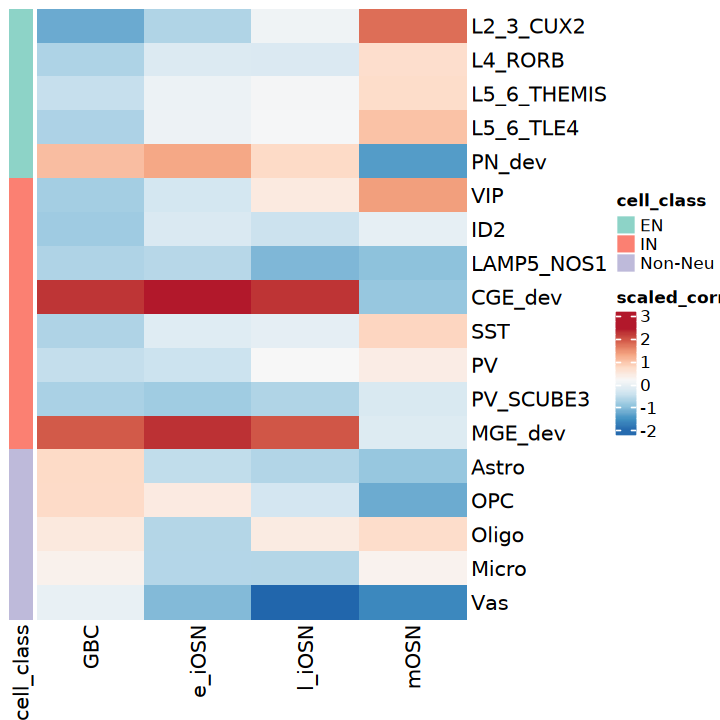

In [87]:

for (nf in c(3000)){#
    for (cor_md in c('spearman')){#,'pearson','kendall'
        for (hvg in c('HVG_ent')){#,'all','HVG_en',
            
        ExN_data <- FindVariableFeatures(ExN_data, nfeatures = nf)
#        ent_N <- FindVariableFeatures(ent_N, nfeatures = nf) 
        if (hvg=='HVG_en'){   
            ExN_data <- FindVariableFeatures(ExN_data, nfeatures = nf,selection.method='mean.var.plot')
        }
        if (hvg=='HVG_ent'){
            ent_N_s <- NormalizeData(ent_N)
            #hvg_ent <- VariableFeatures(ent_N)#
            hvg_ent <-  VariableFeatures(FindVariableFeatures(ent_N_s,nfeatures=nf,
                                                              selection.method='mean.var.plot'), mean.cutoff = c(0.01, 20))#
        }
            
            
            
        #print(length(intersect( VariableFeatures(ExN_data), VariableFeatures(ent_N))))
        corr_he <- c()
        for (ct1 in colnames(pseudo_cluster_ENT)){
            for (ct2 in colnames(pseudo_cluster)){

                
                if(hvg=='HVG'){ intersect_genes <- intersect(VariableFeatures(ExN_data),ExN_data_hvg)}
                if(hvg=='HVG_ent'){ intersect_genes <- intersect( rownames(ExN_data), hvg_ent)}
                if(hvg=='HVG_en'){ intersect_genes <- intersect( VariableFeatures(ExN_data), rownames(ent_N))}
                if(hvg=='all') {intersect_genes <- intersect( rownames(ExN_data), rownames(ent_N))}
                pseudo_clusterx <- pseudo_cluster[intersect_genes,ct2]
                pseudo_cluster_ENTx <- pseudo_cluster_ENT[intersect_genes,ct1]
                x= cor(pseudo_clusterx,pseudo_cluster_ENTx,method = cor_md)
                names(x) <- paste(ct1,ct2)
                corr_he <- c(corr_he,x)
            } 
        }

        corr_he <- as.data.frame(corr_he)
        corr_he$OSN <- str_split(rownames(corr_he),pattern = ' ',simplify = T)[,1]
        corr_he$Brain <- str_split(rownames(corr_he),pattern = ' ',simplify = T)[,2]


        #corr_he 
            
        options(repr.plot.width = 6, repr.plot.height = 6) 
        p1 <- ggplot(corr_he, aes(x=factor(OSN, levels=c('GBC','e_iOSN','l_iOSN','mOSN')), y=factor(Brain, levels = c(
      "L2_3_CUX2", "L4_RORB", "L5_6_THEMIS","L5_6_TLE4",
      "PN_dev","VIP", "ID2", "LAMP5_NOS1", "CGE_dev", "SST", "PV", "PV_SCUBE3",
      "MGE_dev", "Astro", "OPC", "Oligo", "Micro", "Vas")), fill=corr_he))+
        geom_tile(aes(mapping = corr_he))+
            geom_text(aes( label = round(corr_he,2)))+
        scale_fill_viridis_c(option = "cividis")+labs(x='OSN stages',y='Brain cells',fill='corr' )+theme_bw()

        ggsave(p1, file=paste0('./figures/NC/osn_lister/',hvg,'_',cor_md,'_',nf,'goldstein_raw.pdf'), height=6, width=5)
        
        library(tidyr)
        library(dplyr)
        library(tibble)

        xxx <- corr_he %>%
          pivot_wider(names_from = Brain, values_from = corr_he,id_cols = OSN)


        xxx <- column_to_rownames(xxx, var = "OSN")
        xxxx <- apply(xxx,1,scale)
        rownames(xxxx) <- colnames(xxx)

        celltype_meta <- lister@colData[,c( 'major_clust',"cell_type")]
        rownames(celltype_meta) <- celltype_meta$major_clust
        celltype_meta$cell_type <- as.character(celltype_meta$cell_type)
        celltype_meta$cell_type[celltype_meta$cell_type=='PN'] <- 'EN'

        cell_typecolor <- c( 'EN'= "#8DD3C7",'IN'=  "#FB8072",'Non-Neu'= "#BEBADA")
        rownames(celltype_meta) <- gsub('-','_',rownames(celltype_meta))
        
        ComplexHeatmap::draw(Heatmap(
        xxxx[,c(2,1,3,4)],    
        cluster_rows = F,
        cluster_columns              = F,
        name='scaled_corr',
        col= colorRamp2(seq(from=min(xxxx),to=max(xxxx),length=9),rev(brewer.pal(11, "RdBu")[c(-1,-11)])),
        row_gap = unit(c(2.5), "mm"),
        show_row_names               = T,
        show_column_names            = T,
        show_row_dend = T,
            left_annotation = rowAnnotation(
        cell_class= celltype_meta[rownames(xxxx),'cell_type'],
       col = list(cell_class = cell_typecolor)
      )
    ))
        
           dev.print(pdf, file=paste0('./figures/NC/osn_lister/',hvg,'_',cor_md,'_',nf,'goldstein_scale.pdf'), height=6, width=5)

    }
    }
    }

In [90]:
write.table(corr_he, file='./data/NC/fs10a_corr_lister_raw.txt', sep='\t', quote = F)
write.table(xxxx, file='./data/NC/f3a_corr_lister_scale.txt', sep='\t', quote = F)

In [20]:
meta.data <- subset(lister@colData, cell_type %in% c("PN") )
#meta.data <- subset(lister@colData , !cell_type %in%c('Poor-Quality'))
set.seed(123)

meta.data$name <- rownames(meta.data)
#meta.data <- meta.data[sample(1:nrow(meta.data),50000),]
ExN_data <- lister[,rownames(meta.data)]

# meta.data <- as.data.frame(meta.data)%>%group_by(stage_id)%>%sample_n(3000)
# ExN_data <- lister[,meta.data$name]


ExN_data <- CreateSeuratObject(counts = as(ExN_data@assays@data$X,"sparseMatrix"), meta.data = meta.data)
ExN_data$major_clust <- meta.data$major_clust
ExN_data$stage_id <- meta.data$stage_id
ExN_data$cluster_stage <- paste( ExN_data$stage_id, ExN_data$major_clust)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“[[<- defined for objects of type "S4" only for subclasses of environment”


In [28]:
library(edgeR)

# pseudo_bulk
pseudo_cluster <- as.data.frame(AggregateExpression(ExN_data, assays = "RNA", return.seurat = F, group.by = c('major_clust', "cluster_stage",'stage_id')[3])$RNA)

# pseudo_bulk ENT
ent_N$cca_N_types_stage_dataset <- paste(ent_N$cca_N_types_stage,ent_N$dataset)
pseudo_cluster_ENT <- as.data.frame(AggregateExpression(ent_N, assays = "RNA", return.seurat = F, group.by = c("cca_N_types_stage"))$RNA)#'dataset',

pseudo_cluster <- log(cpm(pseudo_cluster+1))
pseudo_cluster_ENT <- log(cpm(pseudo_cluster_ENT+1))
colnames(pseudo_cluster_ENT) <- gsub('-','_',colnames(pseudo_cluster_ENT))
colnames(pseudo_cluster) <- gsub('-','_',colnames(pseudo_cluster))

lister_hvgs <- lister_hvg$X[lister_hvg$highly_variable=='True']

In [ ]:
write.table(corr_he, file='./data/NC/fs10a_corr_lister_raw.txt', sep='\t', quote = F)
write.table(xxxx, file='./data/NC/f3a_corr_lister_scale.txt', sep='\t', quote = F)